## Imports

In [1]:
import json
import pandas as pd
import ast

## Load Dataset from hugggingface

#### Dataset info
Data contains following synthetic financial documents that contains various PIIs
<br> Data source: [link](https://huggingface.co/datasets/gretelai/synthetic_pii_finance_multilingual)
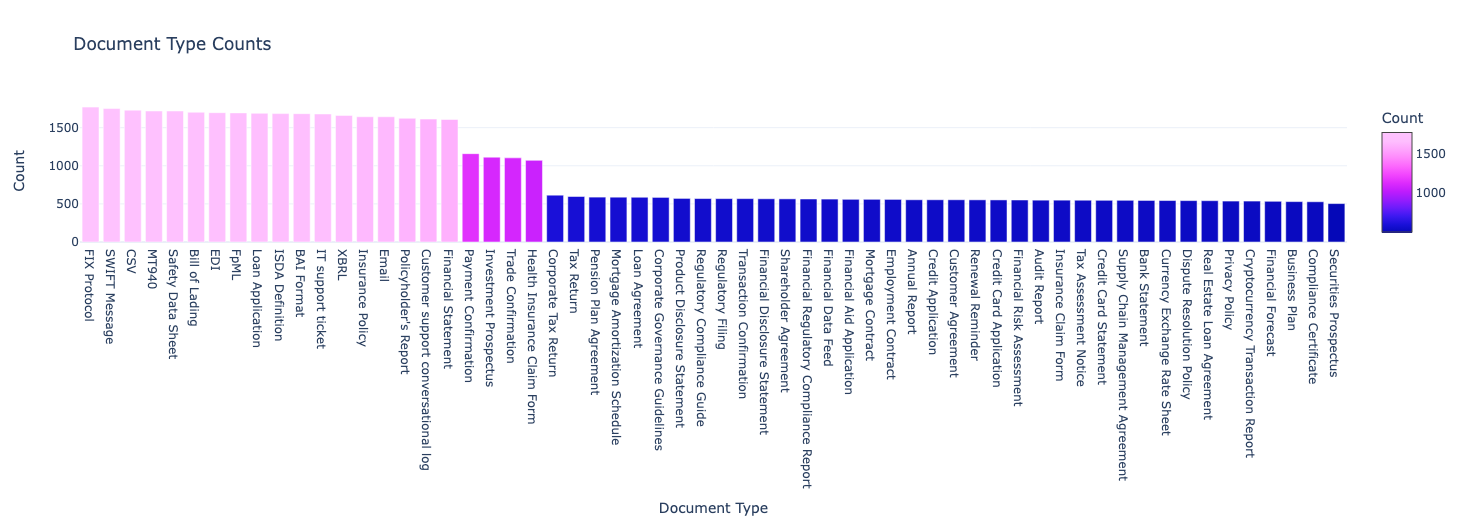

PIIs marked in the data (total 29):
| PII |
| :--- |
|account_pin	|
|api_key |
| bank_routing_number |
| bban |
| company |
| credit_card_number |
| credit_card_security_code |
| customer_id |
| date |
| date_of_birth |
| date_time |
| driver_license_number |
| email |
| employee_id |
| first_name |
| iban |
| ipv4 |
| ipv6 |
| last_name |
| local_latlng |
| name |
| passport_number |
| password |
| phone_number |
| ssn |
| street_address |
| swift_bic_code |
| time |
| user_name |

In [2]:
# Loding data as pd-dataframe
splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}

df_train = pd.read_parquet("hf://datasets/gretelai/synthetic_pii_finance_multilingual/" + splits["train"])
df_test = pd.read_parquet("hf://datasets/gretelai/synthetic_pii_finance_multilingual/" + splits["test"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
df_train.head(3)

,level_0,index,document_type,document_description,expanded_type,expanded_description,language,language_description,domain,generated_text,pii_spans,conformance_score,quality_score,toxicity_score,bias_score,groundedness_score
0,40012,40012,Supply Chain Management Agreement,A legal contract outlining the terms and condi...,Vendor Management Contract,This subtype involves the contractual agreemen...,English,English language as spoken in the United State...,finance,SUPPLY CHAIN MANAGEMENT AGREEMENT\n\nThis Supp...,"[{""start"": 119, ""end"": 141, ""label"": ""date""}, ...",85,90,5,15,95
1,46425,46425,Supply Chain Management Agreement,A legal contract outlining the terms and condi...,Supply Chain Resilience Framework,This subtype details the framework for buildin...,English,English language as spoken in the United State...,finance,SUPPLY CHAIN RESILIENCE FRAMEWORK\n\nThis Supp...,"[{""start"": 119, ""end"": 142, ""label"": ""date""}, ...",92,87,5,12,95
2,4689,4689,Real Estate Loan Agreement,A legal contract outlining terms and condition...,International Real Estate Investment Loan Agre...,This subtype encompasses loans for internation...,Spanish,Spanish language as spoken in Spain or Mexico,finance,CONTRATO DE PRÉSTAMO PARA INVERSIÓN INMOBILIAR...,"[{""start"": 182, ""end"": 209, ""label"": ""street_a...",85,90,5,15,95


In [4]:
df_test.head(3)

,level_0,index,document_type,document_description,expanded_type,expanded_description,language,language_description,domain,generated_text,pii_spans,conformance_score,quality_score,toxicity_score,bias_score,groundedness_score
0,43233,43233,EDI,A structured data exchange standard used to tr...,Shipping Manifest,Create a shipping manifest with a unique shipm...,English,English language as spoken in the United State...,finance,UNB+UNOC:300+IA1234567890:1234567890+IA9876543...,"[{""start"": 310, ""end"": 331, ""label"": ""street_a...",85,90,5,15,95
1,11500,11500,EDI,A structured data exchange standard used to tr...,Customs Invoice,"For the customs invoice subtype, assign distin...",Italian,Italian language as spoken in Italy,finance,UNB+UNOC:303+IT1234567890:1234567890+150317:16...,[],85,90,5,15,95
2,21582,21582,Investment Prospectus,"A formal document detailing the objectives, ri...",Infrastructure Development,Produce a comprehensive report on investment o...,Dutch,Dutch language as spoken in the Netherlands,finance,INVESTEERPROSPECTUS\n\nInnovatieve Infrastruct...,"[{""start"": 21, ""end"": 66, ""label"": ""company""},...",85,92,5,15,88


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50346 entries, 0 to 50345
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   level_0               50346 non-null  int64 
 1   index                 50346 non-null  int64 
 2   document_type         50346 non-null  object
 3   document_description  50346 non-null  object
 4   expanded_type         50346 non-null  object
 5   expanded_description  50346 non-null  object
 6   language              50346 non-null  object
 7   language_description  50346 non-null  object
 8   domain                50346 non-null  object
 9   generated_text        50346 non-null  object
 10  pii_spans             50346 non-null  object
 11  conformance_score     50346 non-null  int64 
 12  quality_score         50346 non-null  int64 
 13  toxicity_score        50346 non-null  int64 
 14  bias_score            50346 non-null  int64 
 15  groundedness_score    50346 non-null

In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5594 entries, 0 to 5593
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   level_0               5594 non-null   int64 
 1   index                 5594 non-null   int64 
 2   document_type         5594 non-null   object
 3   document_description  5594 non-null   object
 4   expanded_type         5594 non-null   object
 5   expanded_description  5594 non-null   object
 6   language              5594 non-null   object
 7   language_description  5594 non-null   object
 8   domain                5594 non-null   object
 9   generated_text        5594 non-null   object
 10  pii_spans             5594 non-null   object
 11  conformance_score     5594 non-null   int64 
 12  quality_score         5594 non-null   int64 
 13  toxicity_score        5594 non-null   int64 
 14  bias_score            5594 non-null   int64 
 15  groundedness_score    5594 non-null   

In [7]:
## Changing strigified lists to list type in both train & test data
df_train['pii_spans']= df_train['pii_spans'].map(ast.literal_eval)
df_test['pii_spans']= df_test['pii_spans'].map(ast.literal_eval)

In [8]:
type(df_train['pii_spans'][0]), type(df_test['pii_spans'][0])

(list, list)

## Filtering data for following conditions:

|  |  |
| :--- | ---: |
| Language: | English |

<br>

| # Scores | What it measures |Desired threshold | Reason |
| :--- | :---: | :---: | :---: |  
| conformance_score |How closely the generated text follows <br> the required style / formatting / policy <br> rules for the task (e.g., “no PII leakage”, <br> correct document structure). | ≥ 80 |  Guarantees the example obeys <br> the required format/policy |
| conformance_score | Overall human‑rated quality of the text <br> (fluency, relevance, completeness). | ≥ 80 |  Keeps fluent, relevant text. |
| toxicity_score | Level of harmful or abusive language <br> present (e.g., profanity, hate speech). |≤ 20 | Removes most toxic content. |
| bias_score | Degree of social or demographic bias <br> (e.g., gender, ethnicity, religion) in the text. |≤ 20 | Limits biased language. |
| groundedness_score | Extent to which the content is factually <br> grounded or supported by evidence <br> (vs. hallucination). | ≥ 70 | Favors factually reliable material. |

In [9]:
## Train data
df_train_filtered = df_train[
              (df_train['language'] == "English") &
              (df_train['conformance_score'] >= 80) &
              (df_train['quality_score'] >= 80) &
              (df_train['toxicity_score'] <= 20) &
              (df_train['bias_score'] <= 20) &
              (df_train['groundedness_score'] >= 70)
            ]

## Test data
df_test_filtered = df_test[
              (df_test['language'] == "English") &
              (df_test['conformance_score'] >= 80) &
              (df_test['quality_score'] >= 80) &
              (df_test['toxicity_score'] <= 20) &
              (df_test['bias_score'] <= 20) &
              (df_test['groundedness_score'] >= 70)
            ]



print("Total rows in filtered train data:", len(df_train_filtered))
print("Total rows in filtered test data:", len(df_test_filtered))
print("\n")
print("Number of empty PII [] rows in train data, where PII detection is not required:", len(df_train_filtered[df_train_filtered['pii_spans'].map(len) == 0]))
print("Number of empty PII [] rows in test data, where PII detection is not required:", len(df_test_filtered[df_test_filtered['pii_spans'].map(len) == 0]))

Total rows in filtered train data: 25948
Total rows in filtered test data: 2962


Number of empty PII [] rows in train data, where PII detection is not required: 1705
Number of empty PII [] rows in test data, where PII detection is not required: 195


## Preparing data for fine-tuning

In [10]:
## Structure the Output field for training data
def clean_and_parse_spans(spans_entry, text):
    if spans_entry is None: return []
    all_spans = []
    for item in spans_entry:
        if isinstance(item, dict):
            start = item.get('start')
            end = item.get('end')
            label = item.get('label')
            if start is not None and end is not None and label is not None:
                all_spans.append({
                    "entity": text[int(start):int(end)],
                    "label": label.upper(),
                    "start": int(start),
                    "end": int(end)
                })
    return all_spans



## Combine (System Prompt + Input text + Json Output) in one long string
def convert_to_sft_format(dataframe):
    sft_data = []
    system_prompt = (
        "You are a secure, enterprise-grade financial data privacy engine. "
        "Analyze the input text and extract all instances of Personally Identifiable Information (PII). "
        "Output your findings strictly as a valid JSON array of objects containing 'entity', 'label', 'start', and 'end' keys. If no PII is found, return an empty array []."
    )
    for _, row in dataframe.iterrows():
        text = row['generated_text']
        spans = clean_and_parse_spans(row['pii_spans'], text)
        formatted_prompt = f"### System:\n{system_prompt}\n\n### Input:\n{text}\n\n### Output:\n{json.dumps(spans)}"
        sft_data.append({"text": formatted_prompt})
    return sft_data

In [11]:
formatted_train_dataset = convert_to_sft_format(df_train_filtered)
formatted_test_dataset = convert_to_sft_format(df_test_filtered)

if len(formatted_train_dataset) == len(df_train_filtered) and len(formatted_test_dataset) == len(df_test_filtered):
  print(f"Formatted train & test data ready!")

Formatted train & test data ready!


In [12]:
formatted_train_dataset[:2]

[{'text': '### System:\nYou are a secure, enterprise-grade financial data privacy engine. Analyze the input text and extract all instances of Personally Identifiable Information (PII). Output your findings strictly as a valid JSON array of objects containing \'entity\', \'label\', \'start\', and \'end\' keys. If no PII is found, return an empty array [].\n\n### Input:\nSUPPLY CHAIN MANAGEMENT AGREEMENT\n\nThis Supply Chain Management Agreement (the "Agreement") is entered into as of this 1st day of March, 2021 (the "Effective Date"), by and between Cameron-Mcknight, a company organized and existing under the laws of the state of Delaware, with its head office located at 81685 Lopez Lodge, Apt. 6502, hereinafter referred to as "Cameron-Mcknight", and Jann N. Butte, an individual with a mailing address of 81685 Lopez Lodge, Apt. 6502.\n\nWHEREAS, Cameron-Mcknight desires to engage the services of Vendor for the provision of goods and services in connection with Cameron-Mcknight\'s supply

## Save the data files

In [13]:
# Export to JSONL
for filename, dataset in [("fin_pii_train.jsonl", formatted_train_dataset), ("fin_pii_test.jsonl", formatted_test_dataset)]:
    with open(filename, "w", encoding="utf-8") as f:
        for entry in dataset:
            f.write(json.dumps(entry) + "\n")
print("Files saved successfully!")

Files saved successfully!
